In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Baseline Burgers Equation

- Standard PINN training for Burgers Equation

In [ ]:
class PINN(nn.Module):

    def __init__(self,layers):

        super().__init__()

        self.activation = nn.Tanh()
        self.layers = nn.ModuleList()

        for i in range(len(layers)-1):
            self.layers.append(nn.Linear(layers[i],layers[i+1]))

    def forward(self,x):

        for i in range(len(self.layers)-1):
            x = self.activation(self.layers[i](x))

        x = self.layers[-1](x)

        return x

layers = [2,128,128,128,1]
model = PINN(layers).to(device)

In [ ]:
def sample_interior(n):

    x = -1 + 2*torch.rand(n,1, device=device)
    t = torch.rand(n,1, device=device)

    pts = torch.cat([x,t],1)

    pts.requires_grad = True

    return pts

Initial Condition at t = 0


In [ ]:
def sample_initial(n):

    x = -1 + 2*torch.rand(n,1)
    t = torch.zeros_like(x)

    pts = torch.cat([x,t],1)

    u = -torch.sin(np.pi*x)

    return pts,u

Boundary at At x = -1 and x = 1.

In [ ]:
def sample_boundary(n):

    t = torch.rand(n,1)

    left = torch.cat([-torch.ones_like(t),t],1)
    right = torch.cat([torch.ones_like(t),t],1)

    pts = torch.cat([left,right],0)

    u = torch.zeros(2*n,1)

    return pts,u

In [ ]:
nu = 0.01/np.pi

def pde_residual(model,pts):

    u = model(pts)

    grads = torch.autograd.grad(
        u,pts,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    u_x = grads[:,0:1]
    u_t = grads[:,1:2]

    u_xx = torch.autograd.grad(
        u_x,pts,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0][:,0:1]

    residual = u_t + u*u_x - nu*u_xx

    return residual

In [ ]:
def physics_loss(model,pts):

    r = pde_residual(model,pts)

    return torch.mean(r**2)

def initial_loss(model,pts,u):

    pred = model(pts)

    return torch.mean((pred-u)**2)

def boundary_loss(model,pts,u):

    pred = model(pts)

    return torch.mean((pred-u)**2)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 70000

loss_history = []

for epoch in range(epochs):

    optimizer.zero_grad()

    interior = sample_interior(8000).to(device)

    ic_pts, ic_u = sample_initial(1000)
    ic_pts, ic_u = ic_pts.to(device), ic_u.to(device)

    bc_pts, bc_u = sample_boundary(1000)
    bc_pts, bc_u = bc_pts.to(device), bc_u.to(device)

    p_loss = physics_loss(model, interior)
    i_loss = initial_loss(model, ic_pts, ic_u)
    b_loss = boundary_loss(model, bc_pts, bc_u)

    loss = p_loss + i_loss + b_loss

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 500 == 0:
        print(f"Adam Epoch {epoch}: Loss = {loss.item():.6e}")

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Adam Epoch 0: Loss = 5.343527e-01
Adam Epoch 500: Loss = 8.552437e-02
Adam Epoch 1000: Loss = 7.666400e-02
Adam Epoch 1500: Loss = 5.746015e-02
Adam Epoch 2000: Loss = 2.802472e-02
Adam Epoch 2500: Loss = 2.549192e-02
Adam Epoch 3000: Loss = 1.333999e-02
Adam Epoch 3500: Loss = 1.050929e-02
Adam Epoch 4000: Loss = 9.845426e-03
Adam Epoch 4500: Loss = 4.186019e-03
Adam Epoch 5000: Loss = 5.075684e-03
Adam Epoch 5500: Loss = 2.378654e-03
Adam Epoch 6000: Loss = 1.672459e-03
Adam Epoch 6500: Loss = 3.096860e-03
Adam Epoch 7000: Loss = 1.516593e-03
Adam Epoch 7500: Loss = 8.886484e-04
Adam Epoch 8000: Loss = 7.674690e-04
Adam Epoch 8500: Loss = 7.562873e-04
Adam Epoch 9000: Loss = 2.953770e-03
Adam Epoch 9500: Loss = 7.741972e-04
Adam Epoch 10000: Loss = 4.851485e-04
Adam Epoch 10500: Loss = 2.254620e-03
Adam Epoch 11000: Loss = 2.944343e-03
Adam Epoch 11500: Loss = 3.895847e-04
Adam Epoch 12000: Loss = 3.368233e-04
Adam Epoch 12500: Loss = 3.448028e-04
Adam Epoch 13000: Loss = 3.300029e-0

In [ ]:
optimizer = torch.optim.LBFGS(
    model.parameters(),
    lr=1.0,
    max_iter=500
)

def closure():

    optimizer.zero_grad()

    interior = sample_interior(8000).to(device)

    ic_pts, ic_u = sample_initial(1000)
    ic_pts, ic_u = ic_pts.to(device), ic_u.to(device)

    bc_pts, bc_u = sample_boundary(1000)
    bc_pts, bc_u = bc_pts.to(device), bc_u.to(device)

    p_loss = physics_loss(model, interior)
    i_loss = initial_loss(model, ic_pts, ic_u)
    b_loss = boundary_loss(model, bc_pts, bc_u)

    loss = 10*p_loss + i_loss + b_loss

    loss.backward()

    return loss

optimizer.step(closure)

tensor(0.0122, device='cuda:0', grad_fn=<AddBackward0>)

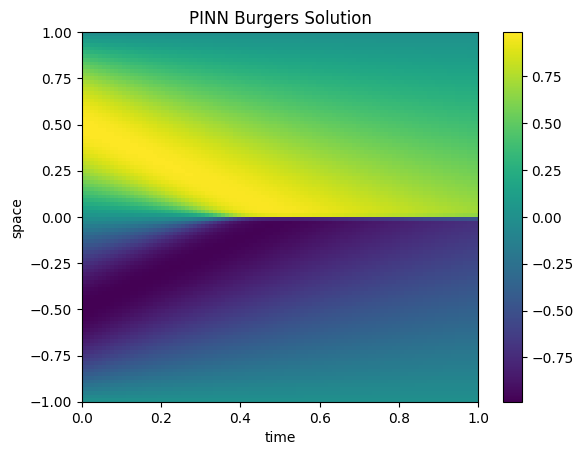

In [ ]:
x = torch.linspace(-1,1,100)
t = torch.linspace(0,1,100)

X,T = torch.meshgrid(x,t,indexing="ij")

pts = torch.stack([X.flatten(),T.flatten()],1).to(device)

with torch.no_grad():
    pred = model(pts).cpu()

pred = pred.reshape(100,100)

plt.imshow(pred,extent=[0,1,-1,1],aspect='auto')
plt.xlabel("time")
plt.ylabel("space")
plt.title("PINN Burgers Solution")
plt.colorbar()
plt.show()

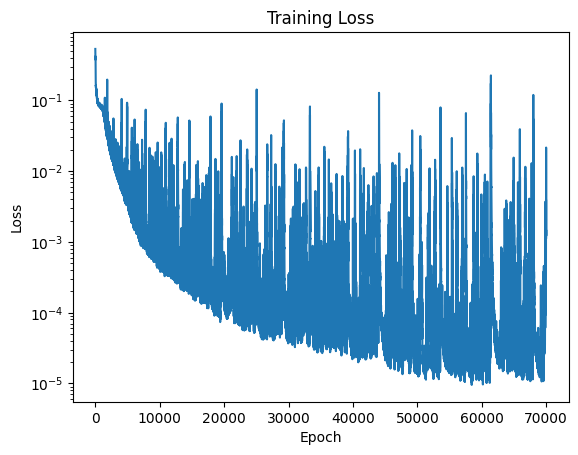

In [ ]:
plt.figure()
plt.plot(loss_history)
plt.yscale("log")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

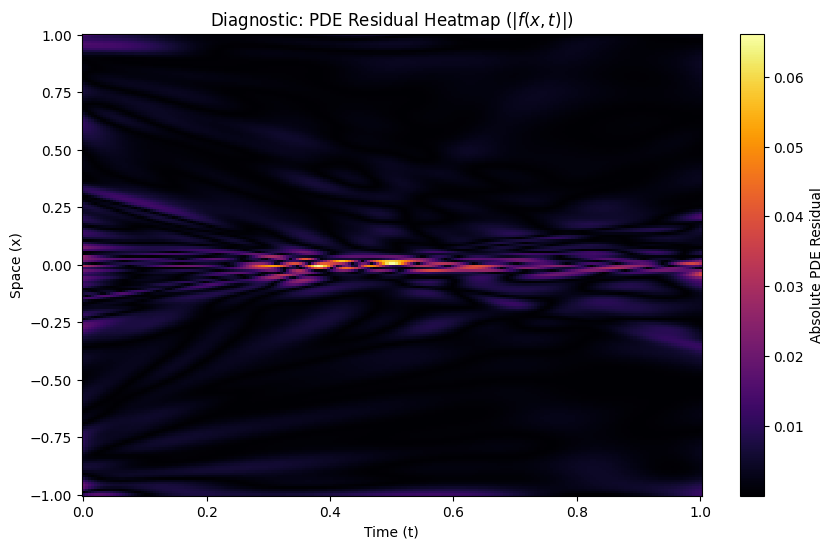

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def plot_pde_residual(model, nu, x_range, t_range, resolution=200):
    x = np.linspace(x_range[0], x_range[1], resolution)
    t = np.linspace(t_range[0], t_range[1], resolution)
    X, T = np.meshgrid(x, t)

    device = next(model.parameters()).device
    x_flat = torch.tensor(X.flatten()[:, None], dtype=torch.float32, device=device, requires_grad=True)
    t_flat = torch.tensor(T.flatten()[:, None], dtype=torch.float32, device=device, requires_grad=True)

    u = model(torch.cat([x_flat, t_flat], dim=1))

    u_xt = torch.autograd.grad(u, [x_flat, t_flat], grad_outputs=torch.ones_like(u), create_graph=True)
    u_x = u_xt[0]
    u_t = u_xt[1]

    u_xx = torch.autograd.grad(u_x, x_flat, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]

    residual = u_t + u * u_x - nu * u_xx
    residual_plot = torch.abs(residual).detach().cpu().numpy().reshape(resolution, resolution)

    plt.figure(figsize=(10, 6))
    plt.pcolormesh(T, X, residual_plot, cmap='inferno', shading='auto')
    plt.colorbar(label='Absolute PDE Residual')
    plt.xlabel('Time (t)')
    plt.ylabel('Space (x)')
    plt.title('Diagnostic: PDE Residual Heatmap ($|f(x,t)|$)')
    plt.show()

plot_pde_residual(model, nu=0.01/np.pi, x_range=[-1, 1], t_range=[0, 1])

In [ ]:
print("Physics loss:",p_loss.item())
print("IC loss:",i_loss.item())
print("BC loss:",b_loss.item())

Physics loss: 0.00119834637735039
IC loss: 0.0001954930485226214
BC loss: 3.7065961805637926e-05


# Fourier Burgers Equation PINN

In [ ]:
class FourierFeatures(torch.nn.Module):

    def __init__(self, input_dim, mapping_size=32, scale=5):
        super().__init__()

        B = torch.randn((input_dim, mapping_size)) * scale
        self.register_buffer("B", B)

    def forward(self, x):

        x_proj = 2 * np.pi * x @ self.B

        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

In [ ]:
class FourierPINN(nn.Module):

    def __init__(self):

        super().__init__()

        self.embed = FourierFeatures(2, mapping_size=32)

        self.net = nn.Sequential(
            nn.Linear(64,128),
            nn.Tanh(),

            nn.Linear(128,128),
            nn.Tanh(),

            nn.Linear(128,128),
            nn.Tanh(),

            nn.Linear(128,1)
        )

    def forward(self,x):

        x = self.embed(x)

        return self.net(x)

In [ ]:
model = FourierPINN().to(device)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 70000

loss_history = []

for epoch in range(epochs):

    optimizer.zero_grad()

    interior = sample_interior(8000).to(device)

    ic_pts, ic_u = sample_initial(1000)
    ic_pts, ic_u = ic_pts.to(device), ic_u.to(device)

    bc_pts, bc_u = sample_boundary(1000)
    bc_pts, bc_u = bc_pts.to(device), bc_u.to(device)

    p_loss = physics_loss(model, interior)
    i_loss = initial_loss(model, ic_pts, ic_u)
    b_loss = boundary_loss(model, bc_pts, bc_u)

    loss = p_loss + i_loss + b_loss

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 500 == 0:
        print(f"Adam Epoch {epoch}: Loss = {loss.item():.6e}")

Adam Epoch 0: Loss = 3.449820e+00
Adam Epoch 500: Loss = 3.346210e-01
Adam Epoch 1000: Loss = 1.082523e-01
Adam Epoch 1500: Loss = 8.726314e-02
Adam Epoch 2000: Loss = 7.394347e-02
Adam Epoch 2500: Loss = 6.041228e-02
Adam Epoch 3000: Loss = 4.677477e-02
Adam Epoch 3500: Loss = 3.880292e-02
Adam Epoch 4000: Loss = 3.565107e-02
Adam Epoch 4500: Loss = 3.491132e-02
Adam Epoch 5000: Loss = 2.136248e-02
Adam Epoch 5500: Loss = 2.448336e-02
Adam Epoch 6000: Loss = 1.369901e-02
Adam Epoch 6500: Loss = 1.115742e-02
Adam Epoch 7000: Loss = 1.623031e-02
Adam Epoch 7500: Loss = 7.995602e-03
Adam Epoch 8000: Loss = 6.762674e-03
Adam Epoch 8500: Loss = 1.280217e-02
Adam Epoch 9000: Loss = 1.834280e-02
Adam Epoch 9500: Loss = 1.128185e-02
Adam Epoch 10000: Loss = 5.500746e-03
Adam Epoch 10500: Loss = 7.413557e-03
Adam Epoch 11000: Loss = 8.508334e-03
Adam Epoch 11500: Loss = 4.895919e-03
Adam Epoch 12000: Loss = 4.378363e-03
Adam Epoch 12500: Loss = 4.979855e-03
Adam Epoch 13000: Loss = 3.807302e-0

In [ ]:
optimizer = torch.optim.LBFGS(
    model.parameters(),
    lr=1.0,
    max_iter=500
)

def closure():

    optimizer.zero_grad()

    interior = sample_interior(8000).to(device)

    ic_pts, ic_u = sample_initial(1000)
    ic_pts, ic_u = ic_pts.to(device), ic_u.to(device)

    bc_pts, bc_u = sample_boundary(1000)
    bc_pts, bc_u = bc_pts.to(device), bc_u.to(device)

    p_loss = physics_loss(model, interior)
    i_loss = initial_loss(model, ic_pts, ic_u)
    b_loss = boundary_loss(model, bc_pts, bc_u)

    loss = 10*p_loss + i_loss + b_loss

    loss.backward()

    return loss

optimizer.step(closure)

tensor(0.0103, device='cuda:0', grad_fn=<AddBackward0>)

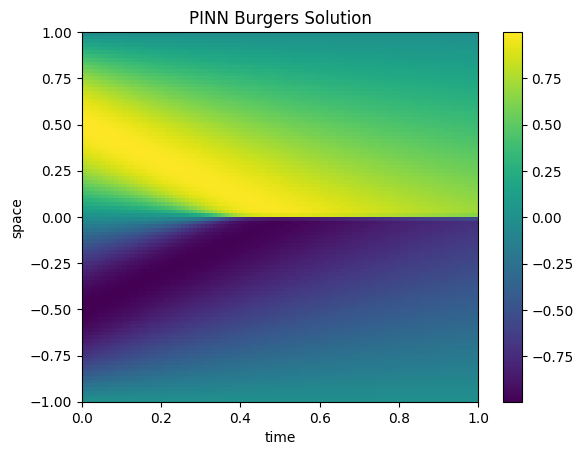

In [ ]:
x = torch.linspace(-1,1,100)
t = torch.linspace(0,1,100)

X,T = torch.meshgrid(x,t,indexing="ij")

pts = torch.stack([X.flatten(),T.flatten()],1).to(device)

with torch.no_grad():
    pred = model(pts).cpu()

pred = pred.reshape(100,100)

plt.imshow(pred,extent=[0,1,-1,1],aspect='auto')
plt.xlabel("time")
plt.ylabel("space")
plt.title("PINN Burgers Solution")
plt.colorbar()
plt.show()

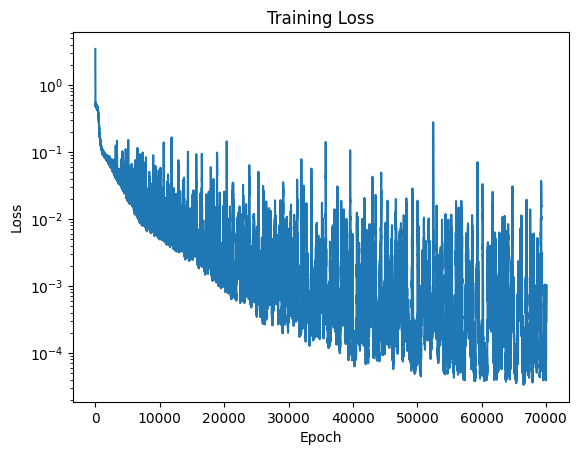

In [ ]:
plt.figure()
plt.plot(loss_history)
plt.yscale("log")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
print("Physics loss:",p_loss.item())
print("IC loss:",i_loss.item())
print("BC loss:",b_loss.item())

Physics loss: 0.001026528188958764
IC loss: 4.958060344506521e-06
BC loss: 2.0851855424552923e-06


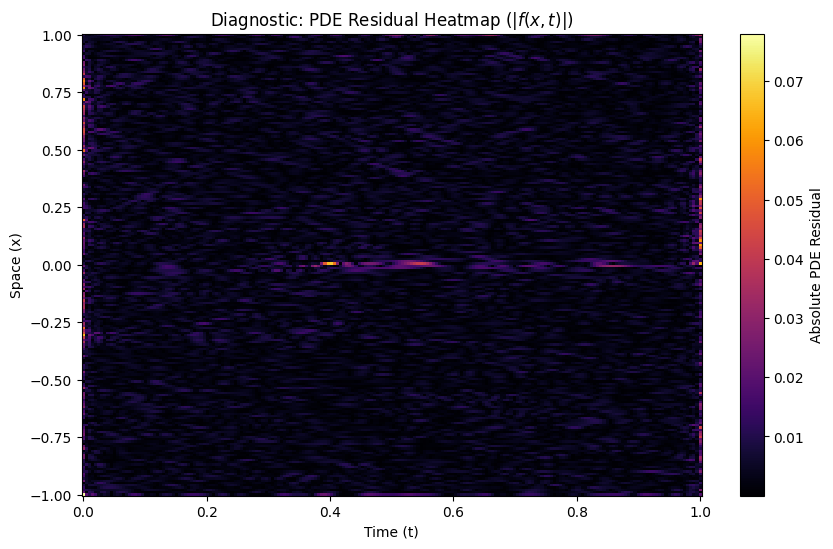

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def plot_pde_residual(model, nu, x_range, t_range, resolution=200):
    x = np.linspace(x_range[0], x_range[1], resolution)
    t = np.linspace(t_range[0], t_range[1], resolution)
    X, T = np.meshgrid(x, t)

    device = next(model.parameters()).device
    x_flat = torch.tensor(X.flatten()[:, None], dtype=torch.float32, device=device, requires_grad=True)
    t_flat = torch.tensor(T.flatten()[:, None], dtype=torch.float32, device=device, requires_grad=True)

    u = model(torch.cat([x_flat, t_flat], dim=1))

    u_xt = torch.autograd.grad(u, [x_flat, t_flat], grad_outputs=torch.ones_like(u), create_graph=True)
    u_x = u_xt[0]
    u_t = u_xt[1]

    u_xx = torch.autograd.grad(u_x, x_flat, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]

    residual = u_t + u * u_x - nu * u_xx
    residual_plot = torch.abs(residual).detach().cpu().numpy().reshape(resolution, resolution)

    plt.figure(figsize=(10, 6))
    plt.pcolormesh(T, X, residual_plot, cmap='inferno', shading='auto')
    plt.colorbar(label='Absolute PDE Residual')
    plt.xlabel('Time (t)')
    plt.ylabel('Space (x)')
    plt.title('Diagnostic: PDE Residual Heatmap ($|f(x,t)|$)')
    plt.show()

plot_pde_residual(model, nu=0.01/np.pi, x_range=[-1, 1], t_range=[0, 1])

# Burgers Equation Using PINNs

## Problem Setup

The **1D viscous Burgers equation** is solved using a **Physics-Informed Neural Network (PINN)**:

$$
u_t + u u_x = \nu u_{xx}
$$

where

$$
\nu = \frac{0.01}{\pi}
$$

The spatial and temporal domains are:

- $x \in [-1,1]$
- $t \in [0,1]$

---

## Initial Condition

$$
u(x,0) = -\sin(\pi x)
$$

---

## Boundary Conditions

$$
u(-1,t) = 0
$$

$$
u(1,t) = 0
$$

This configuration is commonly used in **PINN benchmarks** because the solution develops **steep gradients during evolution**, making it a challenging nonlinear PDE problem.

---

# Standard PINN

## Model

A **fully connected neural network** with **tanh activation functions** is used to approximate the solution

$$
u(x,t)
$$

The PINN is trained by minimizing three components:

- **PDE residual loss**
- **Initial condition loss**
- **Boundary condition loss**

### Collocation Points

- **Interior collocation points** enforce the PDE.
- **Initial points** enforce the initial condition.
- **Boundary points** enforce the boundary conditions.

---

## Training Strategy

Training uses a **two-stage optimization scheme**:

1. **Adam optimizer** – coarse optimization  
2. **L-BFGS optimizer** – refinement

This hybrid strategy improves convergence when minimizing the physics residual.

---

## Results

The **standard PINN** reproduces the global structure of the Burgers solution:

- Sinusoidal initial condition
- Wave steepening over time
- Symmetric Burgers dynamics

The PDE residual remains small across most of the domain, with slightly higher values near the **shock region around $x \approx 0$**.

This region contains **steep gradients**, which are challenging for standard PINNs.

---

# Fourier Feature PINN

## Intended Hypotheses

Standard neural networks tend to learn **low-frequency components** more easily than **high-frequency structures**.

Since Burgers dynamics produce **sharp spatial gradients**, this can limit the model's representation capacity.

---

## Method

To address this limitation, **Fourier feature embeddings** are introduced before the neural network.

The input coordinates are mapped as

$$
(x,t) \rightarrow [\sin(Bx), \cos(Bx)]
$$

This expands the input representation using **periodic basis functions**.

---

## Results

The **Fourier PINN** produces:

- Sharper representation of the evolving wave
- Better modeling of **steep gradients near the shock region**

The **PDE residual heatmap** also shows a more consistent distribution of error across the domain.

---

# Diagnostics

Two visualizations are used to evaluate the model.

## Solution Heatmap

Shows the predicted Burgers solution across **space and time**.

## PDE Residual Heatmap

Displays the magnitude of the physics residual:

$$
\left| u_t + u u_x - \nu u_{xx} \right|
$$

This highlights regions where the **physics constraint is hardest for the network to satisfy**.

Residual values are lowest across most of the domain and increase slightly near the **shock region**, which is expected due to the large gradients present there.

---

# Summary

Both models successfully solve the **Burgers equation using physics-informed training**.

### Standard PINN
- Captures the overall dynamics
- Correctly models the global solution

### Fourier PINN
- Improves representation of **sharp spatial features**
- Better handles **high-frequency gradients**

These results demonstrate how **feature embeddings can enhance PINN performance when modeling nonlinear PDEs with steep gradients**.